# 04 · Predictive Analytics — Forecasting & Stockout Risk

**What's likely to happen.** Two global LightGBM models trained across all
2,035 real SKU×Warehouse series at once (not 2,035 separate models — the
same shape used by top M5-competition solutions, and the only approach that
scales to a network this size):

1. **Weekly demand forecast** — evaluated against classical per-series
   baselines (moving average, Exponential Smoothing) on a representative
   sample, so the global-model choice is justified with evidence, not just
   asserted.
2. **Stockout-risk classifier** for 7/14/30-day horizons.

Then an **Inventory Health Score** blending both models' outputs with the
Phase 3 KPI table, plus SHAP explainability — the grounding the Phase 7 AI
Advisor queries when it explains *why* a SKU is flagged.

In [1]:
!pip -q install lightgbm shap statsmodels 2>&1 | tail -5

In [2]:
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJECT_ROOT = Path('/content/drive/MyDrive/inventory-intelligence-gsc')
except ImportError:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

import predictive_models as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DB_PATH = PROJECT_ROOT / "data" / "inventory_performance.db"
KPI_DIR = PROJECT_ROOT / "data" / "processed" / "kpi_tables"
OUT_DIR = PROJECT_ROOT / "data" / "processed"

tables = pm.load_star_schema(DB_PATH)
print("Loaded:", {k: v.shape for k, v in tables.items()})

Loaded: {'fact_inventory': (1487585, 7), 'fact_demand': (1487585, 4), 'dim_sku': (1540, 6), 'dim_warehouse': (19, 4), 'dim_replenishment_policy': (2035, 10)}


## 1. Weekly demand forecast — global LightGBM

In [3]:
weekly = pm.build_weekly_panel(tables["fact_demand"], tables["dim_sku"], tables["dim_warehouse"])
weekly_feat = pm.add_forecast_features(weekly)
forecast_result = pm.train_forecast_model(weekly_feat)

print(f"Test WAPE:  {forecast_result['wape']:.3f}   (lower is better)")
print(f"Test MASE:  {forecast_result['mase']:.3f}   (< 1.0 = beats a naive last-value forecast)")

forecast_result["test_predictions"].to_parquet(OUT_DIR / "forecast_test_predictions.parquet", index=False)

Test WAPE:  0.409   (lower is better)
Test MASE:  0.786   (< 1.0 = beats a naive last-value forecast)


### 1a. Classical baselines vs. the global model, on a representative sample

Picks 4 SKUs from each ABC class and compares Moving Average, Exponential
Smoothing, and the global LightGBM's WAPE on the *same* held-out weeks —
fitting 2,035 individual ETS/SARIMA models wasn't attempted (too slow to
retrain routinely and not how a production forecasting system for a network
this size would actually be built), but this sample makes the trade-off
visible rather than assumed.

In [4]:
sample_pairs = []
for cls in ["A", "B", "C"]:
    skus = tables["dim_sku"][tables["dim_sku"]["abc_class"] == cls]["sku"].head(5).tolist()
    for s in skus:
        wh = weekly[weekly["sku"] == s]["warehouse_id"].iloc[0]
        sample_pairs.append((s, wh))

baseline_cmp = pm.classical_baseline_comparison(weekly, sample_pairs, forecast_result)
baseline_cmp["best_method"] = baseline_cmp[["wape_moving_avg", "wape_exp_smoothing", "wape_global_lightgbm"]].idxmin(axis=1)
display(baseline_cmp)
print()
print("Average WAPE by method:")
print(baseline_cmp[["wape_moving_avg", "wape_exp_smoothing", "wape_global_lightgbm"]].mean())

,sku,warehouse_id,wape_moving_avg,wape_exp_smoothing,wape_global_lightgbm,best_method
0,1699767,PLANT04,0.176582,0.183630,0.171433,wape_global_lightgbm
1,1682826,PLANT03,0.225000,0.216667,0.231094,wape_exp_smoothing
2,1689780,PLANT02,0.435897,0.435897,0.440170,wape_moving_avg
3,1664343,PLANT05,0.269231,0.265436,0.265468,wape_exp_smoothing
4,1684724,PLANT02,0.392157,0.372549,0.374608,wape_exp_smoothing
5,1696820,PLANT05,0.211921,0.180310,0.165411,wape_global_lightgbm
6,1682983,PLANT03,0.442308,0.400872,0.405065,wape_exp_smoothing
7,1693453,PLANT03,0.469697,0.468291,0.473415,wape_exp_smoothing
8,1699946,PLANT03,0.769231,0.514671,0.555925,wape_exp_smoothing
9,1669409,PLANT03,0.256410,0.166667,0.191913,wape_exp_smoothing



Average WAPE by method:
wape_moving_avg         0.454401
wape_exp_smoothing      0.433599
wape_global_lightgbm    0.444011
dtype: float64


## 2. Stockout-risk classifiers (7 / 14 / 30-day horizons)

In [5]:
stockout_df = pm.build_stockout_dataset(
    tables["fact_inventory"], tables["fact_demand"], tables["dim_sku"],
    tables["dim_warehouse"], tables["dim_replenishment_policy"],
)
print("Stockout training dataset:", stockout_df.shape)

stockout_models = pm.train_stockout_models(stockout_df)
for h, res in stockout_models.items():
    print(f"  {h:>2}d horizon — AUC: {res['test_auc']:.3f}  AvgPrecision: {res['test_avg_precision']:.3f}  "
          f"positive rate (train/test): {res['positive_rate_train']:.1%}/{res['positive_rate_test']:.1%}")

Stockout training dataset: (205535, 21)


   7d horizon — AUC: 0.954  AvgPrecision: 0.264  positive rate (train/test): 1.7%/1.6%
  14d horizon — AUC: 0.934  AvgPrecision: 0.334  positive rate (train/test): 3.4%/3.0%
  30d horizon — AUC: 0.897  AvgPrecision: 0.432  positive rate (train/test): 7.2%/6.0%


## 3. SHAP — why the models say what they say

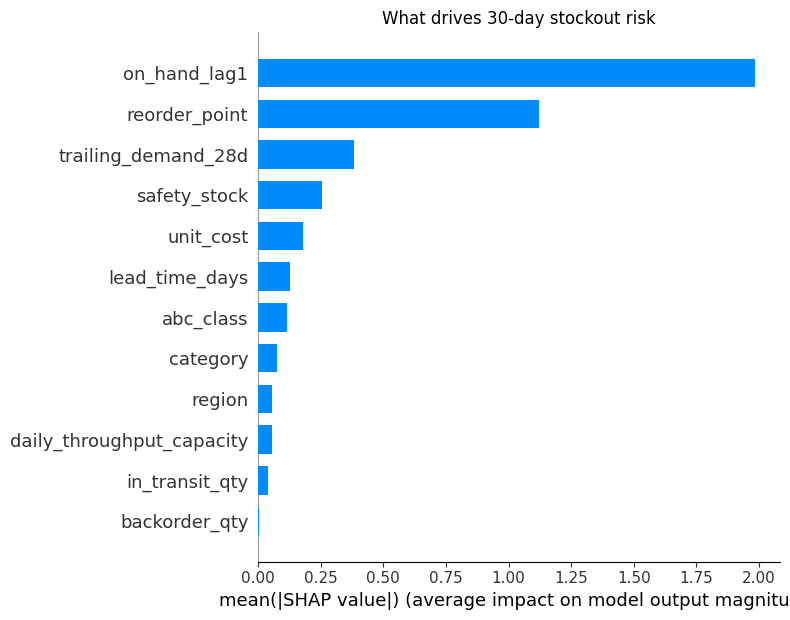

In [6]:
import shap

model_30d = stockout_models[30]["model"]
feat_cols = stockout_models[30]["feature_cols"]
sample_X = stockout_df[feat_cols].sample(min(3000, len(stockout_df)), random_state=42)
for c in ["abc_class", "category", "region"]:
    sample_X[c] = sample_X[c].astype("category")

explainer = shap.TreeExplainer(model_30d)
shap_values = explainer.shap_values(sample_X)

plt.figure()
shap.summary_plot(shap_values, sample_X, plot_type="bar", show=False)
plt.title("What drives 30-day stockout risk")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "phase4_shap_stockout_30d.png", dpi=130, bbox_inches="tight")
plt.show()

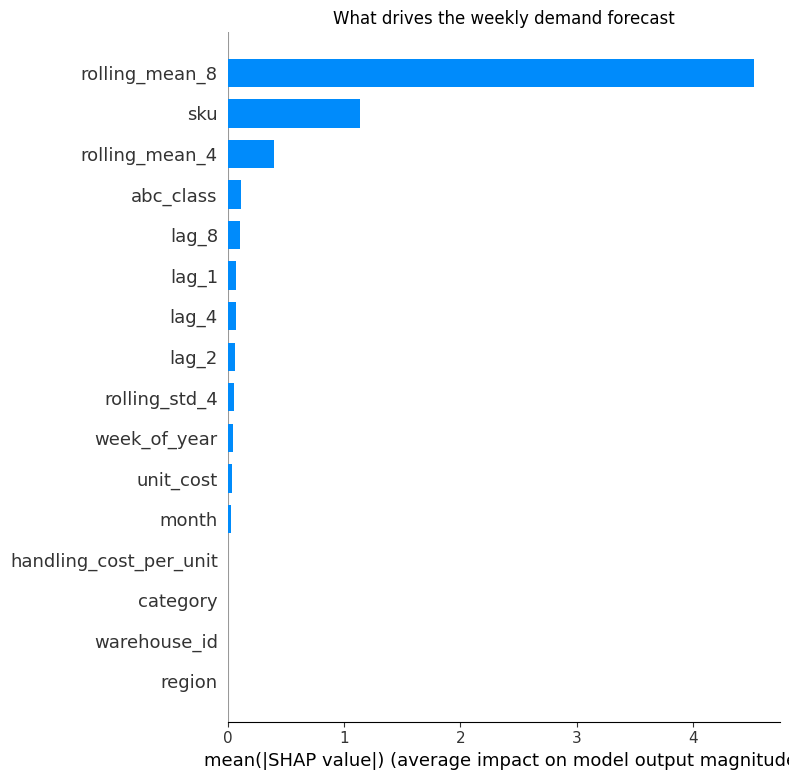

In [7]:
fc_model = forecast_result["model"]
fc_feat_cols = forecast_result["feature_cols"]
fc_sample = forecast_result["test_predictions"][fc_feat_cols].sample(min(3000, len(forecast_result["test_predictions"])), random_state=42)
for c in ["sku", "warehouse_id", "abc_class", "category", "region"]:
    fc_sample[c] = fc_sample[c].astype("category")

fc_explainer = shap.TreeExplainer(fc_model)
fc_shap_values = fc_explainer.shap_values(fc_sample)

plt.figure()
shap.summary_plot(fc_shap_values, fc_sample, plot_type="bar", show=False)
plt.title("What drives the weekly demand forecast")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "phase4_shap_forecast.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Inventory Health Score — blends Phase 3 KPIs with the 30-day stockout probability

In [8]:
kpi_snapshot = pd.read_parquet(KPI_DIR / "sku_warehouse_kpi_snapshot.parquet")

# score every current SKU x Warehouse with the 30-day stockout model
full_feat_30d = stockout_models[30]["feature_cols"]
latest_date = tables["fact_inventory"]["date"].max()
latest_state = tables["fact_inventory"][tables["fact_inventory"]["date"] == latest_date].merge(
    tables["fact_demand"].sort_values(["sku", "warehouse_id", "date"]).groupby(
        ["sku", "warehouse_id"])["demand_qty"].apply(lambda s: s.tail(28).mean()).rename("trailing_demand_28d"),
    on=["sku", "warehouse_id"],
).rename(columns={"on_hand_qty": "on_hand_lag1"})
latest_state = latest_state.merge(tables["dim_sku"][["sku", "unit_cost", "abc_class", "category"]], on="sku")
latest_state = latest_state.merge(tables["dim_warehouse"][["warehouse_id", "region", "daily_throughput_capacity"]], on="warehouse_id")
latest_state = latest_state.merge(
    tables["dim_replenishment_policy"][["sku", "warehouse", "lead_time_days", "safety_stock", "reorder_point"]]
    .rename(columns={"warehouse": "warehouse_id"}), on=["sku", "warehouse_id"])
for c in ["abc_class", "category", "region"]:
    latest_state[c] = latest_state[c].astype("category")

latest_state["stockout_prob_30d"] = stockout_models[30]["model"].predict(latest_state[full_feat_30d])
prob_series = latest_state.set_index(latest_state.index)["stockout_prob_30d"]

kpi_snapshot = kpi_snapshot.reset_index(drop=True)
prob_aligned = kpi_snapshot.merge(
    latest_state[["sku", "warehouse_id", "stockout_prob_30d"]], on=["sku", "warehouse_id"], how="left"
)["stockout_prob_30d"].fillna(0)

scored = pm.compute_health_score(kpi_snapshot, prob_aligned)
scored.to_parquet(OUT_DIR / "kpi_tables" / "sku_warehouse_health_scored.parquet", index=False)

print(scored["health_tier"].value_counts())
print()
print("Health score weights:", scored.attrs["health_score_weights"])
scored[["sku", "warehouse_id", "abc_class", "days_of_supply", "inventory_turnover",
        "service_level", "stockout_prob_30d", "is_excess", "inventory_health_score", "health_tier"]].sort_values(
    "inventory_health_score").head(10)

health_tier
Watch       1190
Healthy      823
Critical      22
Name: count, dtype: int64

Health score weights: {'dos': 0.2, 'turnover': 0.15, 'variability': 0.15, 'stockout': 0.25, 'excess': 0.1, 'service': 0.15}


,sku,warehouse_id,abc_class,days_of_supply,inventory_turnover,service_level,stockout_prob_30d,is_excess,inventory_health_score,health_tier
1946,1684725,PLANT04,B,inf,0.000000,0.921053,0.974269,True,16.5,Critical
241,1688290,PLANT02,C,inf,0.000000,1.000000,0.886280,True,19.8,Critical
192,1682835,PLANT02,B,323.10,0.912272,0.834286,0.604514,True,25.1,Critical
167,1680684,PLANT02,B,176.70,1.568543,0.971452,0.647547,True,26.6,Critical
556,1683426,PLANT10,C,inf,0.000000,1.000000,0.612810,True,26.7,Critical
205,1683419,PLANT02,B,420.30,0.728107,0.963333,0.542224,True,28.4,Critical
1532,1697081,PLANT03,C,inf,0.000000,0.910909,0.450725,True,29.4,Critical
889,1684725,PLANT11,B,256.50,2.269900,0.948077,0.489116,True,30.7,Critical
944,1695687,PLANT09,C,208.80,1.534903,0.974286,0.473778,True,31.1,Critical
1401,1689551,PLANT03,B,177.75,2.024965,0.992857,0.454851,True,32.0,Critical


## 5. Saved outputs

- `data/processed/forecast_test_predictions.parquet`
- `data/processed/kpi_tables/sku_warehouse_health_scored.parquet` — the table Power BI's "Inventory Health" page and the AI Advisor both read
- `docs/phase4_shap_stockout_30d.png`, `docs/phase4_shap_forecast.png`

Next: `05_optimization.ipynb` (Phase 5 — Safety Stock / ROP / EOQ / inter-warehouse transfer).